# Preporuci mi slican film: AI za pocetnike

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boba1987/vector-spaces/blob/master/simple_recommender_ai_colab.ipynb)

Napravicemo mali AI sistem koji preporucuje filmove slicne onom koji volis - i usput cemo **videti gde se tacno krije matematika** i zasto nam treba. Sve je objasnjeno korak po korak, kao da prvi put vidis ovakav projekat.

## Sta ces nauciti

1. Kako racunar "vidi" film - tako sto ga pretvorimo u niz brojeva (**vektor**).
2. Kako merimo koliko su dva filma slicna - preko **rastojanja** i **ugla** izmedju vektora.
3. Kako od toga nastaje prava **preporuka** ("posto ti se svideo ovaj, probaj ove").

## Gde je tu matematika (i iz koje knjige)

Koristimo samo osnovne ideje iz dve knjige u ovom repo-u:

- **Vektori** - Gilbert Strang, *Linear Algebra*, Chapter 2 (Vector Spaces): stvari opisujemo brojevima i tretiramo ih kao tacke u prostoru.
- **Slicnost / rastojanje** - *Introduction to Analysis*, Chapter 7 (Metric Spaces): kako izmeriti koliko su dve tacke blizu.

Ne treba ti nikakvo predznanje - svaki korak ima: **sta radimo**, **zasto** (analogija iz zivota), **mala formula** i **veza sa knjigom**.

> Glavna ideja celog projekta u jednoj recenici: **AI preporuka = pretvori stvari u vektore (Ch2), pa izmeri koje su najblize / najslicnije (Ch7).**

## Priprema (pokreni jednom)

Instaliramo tri standardne biblioteke i napravimo dva mala pomocna "alata" za lepsi ispis. Ne moras da razumes ovaj deo - samo ga pokreni.

In [1]:
!pip -q install numpy pandas matplotlib

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({'figure.figsize': (8, 6), 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})


def show_step(broj, naziv):
    # Lep naslov koraka.
    print('=' * 64)
    print(f'  KORAK {broj}: {naziv}')
    print('=' * 64)


def say(naslov, tekst):
    # Kratko objasnjenje u izlazu celije, da tekst i kod budu na istom mestu.
    print(f'\n>> {naslov}')
    for linija in tekst.strip().split('\n'):
        print(f'   {linija.strip()}')


print('Sve spremno. Pokreni celije redom, od vrha ka dnu.')

Matplotlib is building the font cache; this may take a moment.


Sve spremno. Pokreni celije redom, od vrha ka dnu.


## Podaci: opisimo filmove brojevima

**Problem:** racunar ne razume recenicu "ovo je romanticna komedija". Ali razume **brojeve**.

**Resenje:** svaki film ocenimo po nekoliko osobina, ocenom od 0 do 10:
- `akcija` - koliko ima akcije
- `romansa` - koliko je romanticno
- `komedija` - koliko je smesno
- `tempo` - koliko je dinamicno
- `ozbiljnost` - koliko je ozbiljna tema

Tako svaki film postaje red brojeva. To je sve sto AI-u treba za pocetak.

In [3]:
# Osobine kojima opisujemo svaki film (ocene 0-10).
osobine = ['akcija', 'romansa', 'komedija', 'tempo', 'ozbiljnost']

# Mala "baza" filmova. Brojevi su izmisljeni radi primera.
filmovi = {
    'Velika Pljacka':        [9, 1, 2, 9, 6],   # akcioni triler
    'Jurnjava Gradom':       [8, 2, 3, 9, 5],   # akcioni
    'Heroj Bez Straha':      [9, 2, 1, 8, 7],   # akcioni
    'Ljubav u Parizu':       [1, 9, 4, 3, 5],   # romansa
    'Pismo za Tebe':         [1, 9, 3, 2, 6],   # romansa
    'Leto Kada Smo Se Sreli':[2, 8, 5, 4, 4],   # romansa/dramedija
    'Ludi Provod':           [3, 2, 9, 8, 1],   # komedija
    'Kancelarijske Muke':    [1, 3, 9, 5, 2],   # komedija
    'Tihi Okean':            [2, 4, 1, 2, 9],   # ozbiljna drama
    'Poslednji Dan':         [4, 3, 1, 4, 9],   # ozbiljna drama
}

df = pd.DataFrame.from_dict(filmovi, orient='index', columns=osobine)
df.index.name = 'film'

say('Sta smo uradili',
    'Svaki film smo opisali sa 5 brojeva (po jedna ocena za svaku osobinu).\n'
    'Sada je svaki film jedan red u tabeli ispod.')
display(df)
print(f'\nUkupno filmova: {len(df)} | Osobina po filmu: {len(osobine)}')


>> Sta smo uradili
   Svaki film smo opisali sa 5 brojeva (po jedna ocena za svaku osobinu).
   Sada je svaki film jedan red u tabeli ispod.


,akcija,romansa,komedija,tempo,ozbiljnost
film,,,,,
Velika Pljacka,9,1,2,9,6
Jurnjava Gradom,8,2,3,9,5
Heroj Bez Straha,9,2,1,8,7
Ljubav u Parizu,1,9,4,3,5
Pismo za Tebe,1,9,3,2,6
Leto Kada Smo Se Sreli,2,8,5,4,4
Ludi Provod,3,2,9,8,1
Kancelarijske Muke,1,3,9,5,2
Tihi Okean,2,4,1,2,9



Ukupno filmova: 10 | Osobina po filmu: 5


## Korak 1: film je vektor (tacka u prostoru)

**Sta radimo:** red brojeva za jedan film zovemo **vektor**. Vektor mozemo da zamislimo kao **tacku** (ili strelicu od koordinatnog pocetka) u prostoru.

**Zasto:** ako je film tacka, onda "slicni filmovi" = "tacke koje su blizu jedna drugoj". Cela preporuka se svodi na geometriju! Analogija: kao gradovi na mapi - samo sto nasa "mapa" ima 5 pravaca (5 osobina) umesto 2.

**Matematika iza toga:** film je `x = (x1, x2, x3, x4, x5)`, gde je svaki `xi` ocena jedne osobine. Skup svih takvih vektora je **vektorski prostor**.

**Veza sa knjigom:** Strang Ch2 - 2.1 (vektorski prostor: smemo da sabiramo i skaliramo vektore) i 2.3 (svaka osobina je jedna **dimenzija**; nas prostor ima 5 dimenzija).

  KORAK 1: Film je vektor (tacka u prostoru)

>> Primer jednog filma kao vektor
   "Ljubav u Parizu" -> [np.int64(1), np.int64(9), np.int64(4), np.int64(3), np.int64(5)]
   To znaci: akcija=1, romansa=9, komedija=4, tempo=3, ozbiljnost=5.


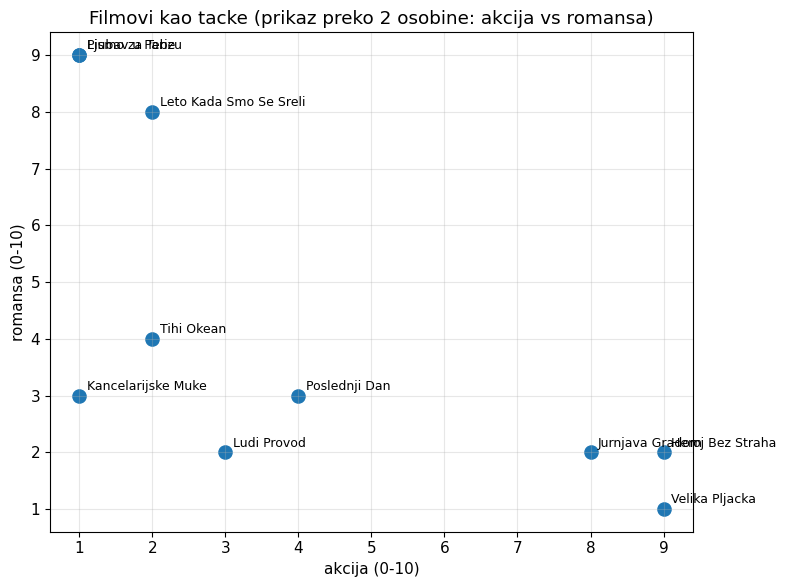


>> Sta vidimo
   Akcioni filmovi se grupisu desno (visoka akcija), romanticni gore-levo (visoka romansa).
   Vec golim okom vidimo da "blizu = slicno". To je sustina preporuke.


In [4]:
show_step(1, 'Film je vektor (tacka u prostoru)')

# Matrica X: svaki red je jedan film kao vektor brojeva.
X = df.values.astype(float)
imena = df.index.tolist()

# Pogledajmo jedan film kao vektor.
primer = 'Ljubav u Parizu'
vek = df.loc[primer].values
say('Primer jednog filma kao vektor',
    f'"{primer}" -> {list(vek)}\n'
    f'To znaci: akcija={vek[0]}, romansa={vek[1]}, komedija={vek[2]}, tempo={vek[3]}, ozbiljnost={vek[4]}.')

# Crtamo filmove koristeci samo 2 osobine (da bismo mogli da ih vidimo na ravnoj slici).
osa_x, osa_y = 'akcija', 'romansa'
fig, ax = plt.subplots()
ax.scatter(df[osa_x], df[osa_y], s=90)
for ime in imena:
    ax.annotate(ime, (df.loc[ime, osa_x] + 0.1, df.loc[ime, osa_y] + 0.1), fontsize=9)
ax.set_xlabel(f'{osa_x} (0-10)'); ax.set_ylabel(f'{osa_y} (0-10)')
ax.set_title('Filmovi kao tacke (prikaz preko 2 osobine: akcija vs romansa)')
plt.tight_layout(); plt.show()

say('Sta vidimo',
    'Akcioni filmovi se grupisu desno (visoka akcija), romanticni gore-levo (visoka romansa).\n'
    'Vec golim okom vidimo da "blizu = slicno". To je sustina preporuke.')

## Korak 2: koliko su dva filma "daleko"?

**Sta radimo:** racunamo **rastojanje** izmedju dva filma (dve tacke). Manje rastojanje = slicniji filmovi.

**Zasto:** to je najprirodniji nacin da kazemo "blizu = slicno". Analogija: vazdusna linija izmedju dva grada - sto je kraca, gradovi su blizi.

**Matematika iza toga (Euklidsko rastojanje):**

\[ d(x, y) = \sqrt{(x_1-y_1)^2 + (x_2-y_2)^2 + \dots + (x_5-y_5)^2} \]

Recima: za svaku osobinu nadjemo razliku, kvadriramo je (da nestane minus i da vece razlike vise "bole"), sve saberemo i izvucemo koren. Isto kao Pitagorina teorema, samo u 5 dimenzija.

**Veza sa knjigom:** Analysis Ch7 - Def 7.1 (sta uopste mora da vazi da bi nesto bilo "rastojanje": nije negativno, simetricno je, i postuje nejednakost trougla) i Ex 7.4/7.5 (bas ova, Euklidska formula).

In [5]:
show_step(2, 'Rastojanje izmedju dva filma (Euklidsko)')

def rastojanje(x, y):
    # d(x,y) = sqrt( zbir kvadrata razlika po svakoj osobini )
    return np.sqrt(np.sum((x - y) ** 2))

# Uporedimo dva slicna i dva razlicita filma.
a, b, c = 'Velika Pljacka', 'Jurnjava Gradom', 'Ljubav u Parizu'
d_slicni = rastojanje(df.loc[a].values, df.loc[b].values)
d_razliciti = rastojanje(df.loc[a].values, df.loc[c].values)

say('Dva akciona filma (treba da budu blizu)',
    f'd("{a}", "{b}") = {d_slicni:.2f}')
say('Akcioni vs romanticni (treba da budu daleko)',
    f'd("{a}", "{c}") = {d_razliciti:.2f}')
print(f'\nManji broj = slicniji. Vidimo: {d_slicni:.2f} < {d_razliciti:.2f}  -> formula se slaze sa intuicijom.')

# Tablica rastojanja od jednog filma do svih ostalih.
pocetni = 'Velika Pljacka'
rastojanja = {ime: rastojanje(df.loc[pocetni].values, df.loc[ime].values) for ime in imena}
tabela_d = pd.Series(rastojanja).sort_values().rename('rastojanje_od_' + pocetni.replace(' ', '_'))
say('Rastojanje od "' + pocetni + '" do svih (sortirano, manje = slicnije)', '')
display(tabela_d.to_frame().round(2))

  KORAK 2: Rastojanje izmedju dva filma (Euklidsko)

>> Dva akciona filma (treba da budu blizu)
   d("Velika Pljacka", "Jurnjava Gradom") = 2.00

>> Akcioni vs romanticni (treba da budu daleko)
   d("Velika Pljacka", "Ljubav u Parizu") = 13.00

Manji broj = slicniji. Vidimo: 2.00 < 13.00  -> formula se slaze sa intuicijom.

>> Rastojanje od "Velika Pljacka" do svih (sortirano, manje = slicnije)
   


,rastojanje_od_Velika_Pljacka
Velika Pljacka,0.00
Jurnjava Gradom,2.00
Heroj Bez Straha,2.00
Poslednji Dan,8.00
Ludi Provod,10.58
Tihi Okean,10.82
Leto Kada Smo Se Sreli,11.66
Kancelarijske Muke,12.21
Ljubav u Parizu,13.00
Pismo za Tebe,13.34


## Korak 3: kada je vazniji "ukus" nego "jacina ocene"

**Problem:** zamisli dva gledaoca. Jedan svemu daje visoke ocene, drugi svemu niske - ali im je **ukus isti** (oboje vole akciju, ne vole romansu). Rastojanje bi ih proglasilo razlicitima samo zato sto su brojevi po velicini razliciti.

**Resenje:** gledamo **ugao** izmedju dva vektora, a ne njihovu duzinu. Ako "gledaju u istom pravcu", ukus je isti.

**Matematika iza toga (cosine slicnost):**

\[ \cos(x, y) = \frac{\langle x, y\rangle}{\lVert x\rVert \, \lVert y\rVert} \]

- `<x,y>` (skalarni proizvod) = saberemo `x1*y1 + x2*y2 + ...`; meri "koliko se poklapaju".
- `||x||` = duzina vektora (delimo njime da bi duzina prestala da bude bitna).
- Rezultat je broj od **-1 do 1**: blizu 1 = isti ukus, oko 0 = nepovezano.

**Zasto bas od -1 do 1?** Zbog **Cauchy-Schwarz** nejednakosti: brojilac `<x,y>` nikada ne moze biti veci od imenioca `||x|| ||y||`. Zato razlomak ostaje izmedju -1 i 1.

**Veza sa knjigom:** Analysis Ch7 - Thm 7.54 (Cauchy-Schwarz) i Ex 7.15 (skalarni proizvod i duzina).

In [6]:
show_step(3, 'Cosine slicnost (gledamo ugao, ne velicinu)')

def cosine(x, y):
    return float(np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y)))

# Pokazimo problem sa "jacinom ocena":
# isti ukus, ali jedan gledalac sve duplira (vece ocene).
ukus_A = np.array([8, 2, 1, 7, 3], dtype=float)
ukus_B = ukus_A * 2          # isti pravac, dvostruke ocene
ukus_C = np.array([1, 9, 8, 2, 6], dtype=float)  # drugaciji ukus

say('Isti ukus, razlicita "jacina" ocena',
    f'A = {list(ukus_A.astype(int))}\nB = {list(ukus_B.astype(int))}  (= A puta 2)')
print(f'   Rastojanje A-B = {rastojanje(ukus_A, ukus_B):.2f}  (veliko! deluje razlicito - a nije)')
print(f'   Cosine    A-B = {cosine(ukus_A, ukus_B):.3f}  (≈1.0 -> prepoznaje da je ukus isti)')

say('Drugaciji ukus',
    f'C = {list(ukus_C.astype(int))}')
print(f'   Cosine A-C = {cosine(ukus_A, ukus_C):.3f}  (nisko -> razlicit ukus)')

# Provera granica iz Cauchy-Schwarz: cosine je uvek u [-1, 1].
sve_kosine = [cosine(df.loc[i].values, df.loc[j].values) for i in imena for j in imena]
print(f'\n[provera] Najmanji cosine={min(sve_kosine):.3f}, najveci={max(sve_kosine):.3f} '
      f'-> zaista ostaje u [-1, 1] (Cauchy-Schwarz, Thm 7.54).')

  KORAK 3: Cosine slicnost (gledamo ugao, ne velicinu)

>> Isti ukus, razlicita "jacina" ocena
   A = [np.int64(8), np.int64(2), np.int64(1), np.int64(7), np.int64(3)]
   B = [np.int64(16), np.int64(4), np.int64(2), np.int64(14), np.int64(6)]  (= A puta 2)
   Rastojanje A-B = 11.27  (veliko! deluje razlicito - a nije)
   Cosine    A-B = 1.000  (≈1.0 -> prepoznaje da je ukus isti)

>> Drugaciji ukus
   C = [np.int64(1), np.int64(9), np.int64(8), np.int64(2), np.int64(6)]
   Cosine A-C = 0.429  (nisko -> razlicit ukus)

[provera] Najmanji cosine=0.370, najveci=1.000 -> zaista ostaje u [-1, 1] (Cauchy-Schwarz, Thm 7.54).


## Korak 4: zasto "normalizujemo"

**Sta radimo:** svaki vektor svedemo na **duzinu 1** (zadrzi pravac, izgubi velicinu). To se zove **normalizacija**.

**Zasto:** da poredjenje bude posteno - da nas ne zavara to sto je neko davao vece brojeve. Analogija: poredimo **oblik** stvari, a ne koliko je velika.

**Matematika iza toga:**
- **Norma** (duzina) vektora: `||x|| = sqrt(x1^2 + x2^2 + ...)`.
- Normalizovan vektor: `x / ||x||` - sada mu je duzina tacno 1.
- Zgodno: cosine slicnost je upravo obican skalarni proizvod **normalizovanih** vektora.

**Veza sa knjigom:** Analysis Ch7 - Def 7.11 (norma = "duzina", sa pravilima: nije negativna, mnozenje brojem mnozi duzinu, vazi nejednakost trougla).

In [7]:
show_step(4, 'Normalizacija (poredimo oblik, ne velicinu)')

def normalizuj(x):
    duzina = np.linalg.norm(x)
    return x / duzina if duzina > 0 else x

v = df.loc['Ljubav u Parizu'].values
v_norm = normalizuj(v)

say('Pre i posle normalizacije',
    f'original = {list(v)}, duzina = {np.linalg.norm(v):.2f}\n'
    f'normalizovan = {np.round(v_norm, 2).tolist()}, duzina = {np.linalg.norm(v_norm):.2f}')

# Dokaz da je cosine = skalarni proizvod normalizovanih vektora.
x = df.loc['Velika Pljacka'].values
y = df.loc['Jurnjava Gradom'].values
levo = cosine(x, y)
desno = float(np.dot(normalizuj(x), normalizuj(y)))
print(f'\n[provera] cosine(x,y) = {levo:.4f}')
print(f'[provera] <x_norm, y_norm> = {desno:.4f}   -> isto! (normalizacija + skalarni proizvod = cosine)')

say('Zakljucak',
    'Posle normalizacije svi vektori imaju istu duzinu (1), pa poredimo samo PRAVAC = ukus.\n'
    'To je tacno ono sto zelimo od preporuke.')

  KORAK 4: Normalizacija (poredimo oblik, ne velicinu)

>> Pre i posle normalizacije
   original = [np.int64(1), np.int64(9), np.int64(4), np.int64(3), np.int64(5)], duzina = 11.49
   normalizovan = [0.09, 0.78, 0.35, 0.26, 0.44], duzina = 1.00

[provera] cosine(x,y) = 0.9910
[provera] <x_norm, y_norm> = 0.9910   -> isto! (normalizacija + skalarni proizvod = cosine)

>> Zakljucak
   Posle normalizacije svi vektori imaju istu duzinu (1), pa poredimo samo PRAVAC = ukus.
   To je tacno ono sto zelimo od preporuke.


## Korak 5: napravi preporuku (sve se spaja)

**Sta radimo:** za film koji volis, izracunamo slicnost prema svim ostalim filmovima, poredjamo ih od najslicnijeg ka najmanje slicnom, i vratimo prvih nekoliko.

**Zasto:** to je cela "magija" preporuke - nema nista vise od ovoga. Sve sto smo radili u koracima 1-4 sada se koristi ovde.

**Matematika iza toga:** koristimo **cosine slicnost** (Korak 3 + 4). Veca slicnost = bolja preporuka.

**Bonus (prag slicnosti):** umesto "daj mi tacno 3", mozemo reci "daj mi sve filmove cija je slicnost preko npr. 0.9". To je ideja **lopte** oko filma (Analysis Ch7, Def 7.18): skup svih tacaka koje su dovoljno blizu.

In [8]:
show_step(5, 'Preporuka filmova')

def preporuci(naziv_filma, n=3):
    if naziv_filma not in df.index:
        print(f'Nemam film "{naziv_filma}" u bazi.'); return None
    osnova = df.loc[naziv_filma].values
    slicnosti = {ime: cosine(osnova, df.loc[ime].values) for ime in imena if ime != naziv_filma}
    rang = pd.Series(slicnosti).sort_values(ascending=False)
    return rang.head(n)

def preporuci_u_lopti(naziv_filma, prag=0.9):
    # Def 7.18: svi filmovi cija je slicnost >= prag (tj. dovoljno "blizu").
    osnova = df.loc[naziv_filma].values
    slicnosti = {ime: cosine(osnova, df.loc[ime].values) for ime in imena if ime != naziv_filma}
    rang = pd.Series(slicnosti).sort_values(ascending=False)
    return rang[rang >= prag]

# Primer 1: akcioni film.
izbor = 'Velika Pljacka'
say(f'Posto ti se svideo: "{izbor}"', 'Top 3 preporuke (po cosine slicnosti):')
display(preporuci(izbor, n=3).rename('slicnost').to_frame().round(3))

# Primer 2: romanticni film.
izbor2 = 'Ljubav u Parizu'
say(f'Posto ti se svideo: "{izbor2}"', 'Top 3 preporuke:')
display(preporuci(izbor2, n=3).rename('slicnost').to_frame().round(3))

# Bonus: prag slicnosti (lopta oko filma).
prag = 0.95
u_lopti = preporuci_u_lopti(izbor, prag=prag)
say(f'Svi filmovi slicniji od {prag} filmu "{izbor}" (Def 7.18 - lopta)',
    f'Pronadjeno: {len(u_lopti)} film(ova).')
display(u_lopti.rename('slicnost').to_frame().round(3))

  KORAK 5: Preporuka filmova

>> Posto ti se svideo: "Velika Pljacka"
   Top 3 preporuke (po cosine slicnosti):


,slicnost
Jurnjava Gradom,0.991
Heroj Bez Straha,0.990
Poslednji Dan,0.829



>> Posto ti se svideo: "Ljubav u Parizu"
   Top 3 preporuke:


,slicnost
Pismo za Tebe,0.989
Leto Kada Smo Se Sreli,0.981
Tihi Okean,0.786



>> Svi filmovi slicniji od 0.95 filmu "Velika Pljacka" (Def 7.18 - lopta)
   Pronadjeno: 2 film(ova).


,slicnost
Jurnjava Gradom,0.991
Heroj Bez Straha,0.990


## Mapa filmova: vidimo preporuke svojim ocima

**Sta radimo:** nacrtamo sve filmove kao tacke i povucemo linije od izabranog filma do njegovih preporuka.

**Zasto:** da se uverimo da preporuke zaista "imaju smisla" - da povezuju bliske tacke. Koristimo 2 osobine (akcija, romansa) za prikaz na ravnoj slici.

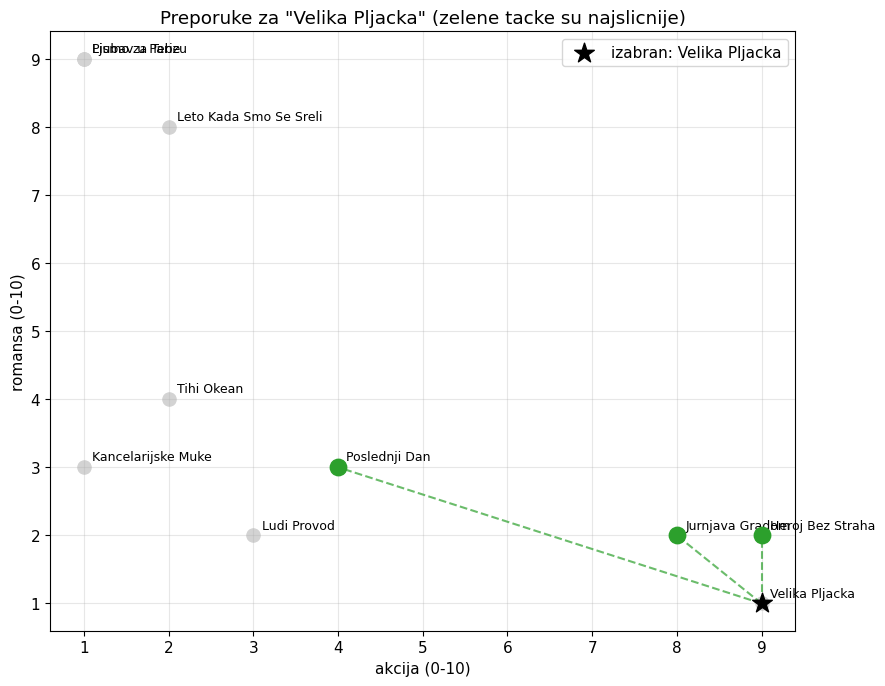


>> Sta vidimo
   Zelene linije idu ka tackama koje su najblize izabranom filmu (zvezdici).
   Preporuka = "nadji najblize tacke", tacno kao sto smo i ocekivali.


In [9]:
izabran = 'Velika Pljacka'
preporuke = preporuci(izabran, n=3)

osa_x, osa_y = 'akcija', 'romansa'
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df[osa_x], df[osa_y], s=90, color='lightgray')

# Izabrani film + linije ka preporukama.
px, py = df.loc[izabran, osa_x], df.loc[izabran, osa_y]
ax.scatter([px], [py], s=220, marker='*', color='black', zorder=5, label=f'izabran: {izabran}')
for ime in preporuke.index:
    qx, qy = df.loc[ime, osa_x], df.loc[ime, osa_y]
    ax.plot([px, qx], [py, qy], '--', color='tab:green', alpha=0.7)
    ax.scatter([qx], [qy], s=140, color='tab:green', zorder=4)

for ime in imena:
    ax.annotate(ime, (df.loc[ime, osa_x] + 0.1, df.loc[ime, osa_y] + 0.1), fontsize=9)

ax.set_xlabel(f'{osa_x} (0-10)'); ax.set_ylabel(f'{osa_y} (0-10)')
ax.set_title(f'Preporuke za "{izabran}" (zelene tacke su najslicnije)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

say('Sta vidimo',
    'Zelene linije idu ka tackama koje su najblize izabranom filmu (zvezdici).\n'
    'Preporuka = "nadji najblize tacke", tacno kao sto smo i ocekivali.')

## Rekapitulacija: gde je bila matematika i zasto

Cestitamo - napravio/la si pravi (mali) AI sistem za preporuke! Evo sta smo koristili i zasto:

| Korak | Sta smo radili | Koja matematika | Zasto nam je trebala |
|---|---|---|---|
| 1 | Film -> niz brojeva | **Vektori** (Strang 2.1, 2.3) | racunar poredi brojeve, ne reci; film postaje tacka |
| 2 | "Koliko su daleko" | **Rastojanje / metrika** (Ch7 Def 7.1, Ex 7.4) | blizu = slicno |
| 3 | "Isti ukus?" | **Cosine + Cauchy-Schwarz** (Ch7 Thm 7.54) | gledamo pravac, ne velicinu ocena; vrednost ostaje u [-1,1] |
| 4 | Posteno poredjenje | **Norma / normalizacija** (Ch7 Def 7.11) | da nas ne zavara ko daje vece brojeve |
| 5 | Prava preporuka | sve gore + **prag/lopta** (Ch7 Def 7.18) | poredjamo po slicnosti i vratimo najbolje |

### Glavna poruka

> **AI preporuka = pretvori stvari u vektore (Strang Ch2), pa izmeri koje su najslicnije (Analysis Ch7).**

Isti recept koriste i veliki sistemi (muzika, kupovina, video) - samo sa milionima stavki i stotinama osobina koje se uce iz podataka. Matematika je ista ova koju si upravo prosao/la.

### Probaj sam/a
- Promeni ocene nekog filma u tabeli (Korak podataka) i ponovo pokreni - vidi kako se preporuke menjaju.
- Dodaj svoj film u `filmovi` recnik.
- U `preporuci(...)` promeni `n`, ili u `preporuci_u_lopti(...)` promeni `prag`.